The following shows a basic bigram language model is trained and how it generates text by learning statistical patterns in sequences.
This is the conceptual foundation of modern language models eg: GPT does the same type of next-token prediction, just with much more sophisticated architectures, larger vocabularies, and massive datasets.

In [ ]:
!wget https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt

--2026-05-07 03:41:25--  https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.02s   

2026-05-07 03:41:25 (8.81 MB/s) - ‘names.txt’ saved [228145/228145]



In [ ]:
words = open('names.txt', 'r').read().splitlines()

In [ ]:
len(words)

32033

In [ ]:
words[:30]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett',
 'victoria',
 'madison',
 'luna',
 'grace',
 'chloe',
 'penelope',
 'layla',
 'riley',
 'zoey',
 'nora']

In [ ]:
from re import M
# 'emma' -> [e, m, m, a]
# [e, m, m] -> a
# [e, m] -> m
# [e] -> m

# [e, m, m] -> {a, b, c, d,..., z}

# "cat sits on a mat" -> [cat, sits, on, a, mat]
# [cat, sits, on, a] -> mat
# [cat, sits, on] -> a
# ...
# [cat] -> sits


# [cat, sita, on, a] -> {mat, chair, table, bed....} <- size of this would be number of possible words in english


# vocab = {<bon>, a, b, c, d, ..., z, <eon>}

# 'emma' -> [<bon>, e, m, m, a, <eon>]

# "training"
# <bon> -> e
# e -> m
# m -> m
# m -> a
# a -> <eon>

# "dreaming" / "inference"
# <bon> -> {e, a, m, ...} -> e -> <bon>e
# e -> {m, l, a, ...} -> m -> <bon>em
# m -> {m, a, <eon>, ...} -> m -> <bon>emm
# m -> {m, a, <eon>, ...} -> a -> <bon>emma
# a -> a -> {<eon>, b, c} -> <eon> -> <bon>emma<eon>

This code builds a training dataset for a simple character-level language model by converting each word into pairs of consecutive characters. For every word, it first creates a pair from the special beginning token '<bon>' to the first character, then creates pairs for every adjacent character in the word (like ('e','m'), ('m','m'), ('m','a') for "emma"), and finally adds a pair from the last character to the special end token '<eon>'. The resulting training_set contains examples of “current character -> next character,” which a model can use to learn the probability of what character usually follows another character and eventually generate new words one character at a time.

In [ ]:
training_set = []
for name in words:
    training_set.append(('<bon>', name[0]))
    for i in range(len(name) - 1):
        # (e,m), (m,m), (m,a)
        training_set.append((name[i], name[i+1]))
    training_set.append((name[-1], '<eon>'))
training_set[:30]

[('<bon>', 'e'),
 ('e', 'm'),
 ('m', 'm'),
 ('m', 'a'),
 ('a', '<eon>'),
 ('<bon>', 'o'),
 ('o', 'l'),
 ('l', 'i'),
 ('i', 'v'),
 ('v', 'i'),
 ('i', 'a'),
 ('a', '<eon>'),
 ('<bon>', 'a'),
 ('a', 'v'),
 ('v', 'a'),
 ('a', '<eon>'),
 ('<bon>', 'i'),
 ('i', 's'),
 ('s', 'a'),
 ('a', 'b'),
 ('b', 'e'),
 ('e', 'l'),
 ('l', 'l'),
 ('l', 'a'),
 ('a', '<eon>'),
 ('<bon>', 's'),
 ('s', 'o'),
 ('o', 'p'),
 ('p', 'h'),
 ('h', 'i')]

In [36]:
from collections import Counter
b = Counter(training_set)
b

Counter({('<bon>', 'e'): 1531,
         ('e', 'm'): 769,
         ('m', 'm'): 168,
         ('m', 'a'): 2590,
         ('a', '<eon>'): 6640,
         ('<bon>', 'o'): 394,
         ('o', 'l'): 619,
         ('l', 'i'): 2480,
         ('i', 'v'): 269,
         ('v', 'i'): 911,
         ('i', 'a'): 2445,
         ('<bon>', 'a'): 4410,
         ('a', 'v'): 834,
         ('v', 'a'): 642,
         ('<bon>', 'i'): 591,
         ('i', 's'): 1316,
         ('s', 'a'): 1201,
         ('a', 'b'): 541,
         ('b', 'e'): 655,
         ('e', 'l'): 3248,
         ('l', 'l'): 1345,
         ('l', 'a'): 2623,
         ('<bon>', 's'): 2055,
         ('s', 'o'): 531,
         ('o', 'p'): 95,
         ('p', 'h'): 204,
         ('h', 'i'): 729,
         ('<bon>', 'c'): 1542,
         ('c', 'h'): 664,
         ('h', 'a'): 2244,
         ('a', 'r'): 3264,
         ('r', 'l'): 413,
         ('l', 'o'): 692,
         ('o', 't'): 118,
         ('t', 't'): 374,
         ('t', 'e'): 716,
         ('e', '<eon>'

This code creates a mapping between characters and integers so the language model can work with numbers instead of raw text. First, it collects all unique characters appearing in words, sorts them, and stores them in chars. Then it builds stoi (“string to integer”), assigning each character a unique numeric ID starting from 1, while reserving 0 for the special beginning token '<bon>' and 27 for the end token '<eon>'. Finally, it creates itos (“integer to string”), which reverses the mapping so integers can be converted back into characters during text generation.

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {c: i + 1 for i, c in enumerate(chars)}
stoi['<bon>'] = 0
stoi['<eon>'] = 27
itos = {i: c for c, i in stoi.items()}

This code creates a 28x28 matrix using PyTorch to store how often one character is followed by another character in the training data. N is initialized with zeros, where rows represent the current character and columns represent the next character. The loop goes through each character pair (ch1, ch2) and its frequency count from b (likely a dictionary of bigram counts). Using stoi, each character is converted into its numeric index (ix1, ix2), and the corresponding cell in the matrix is filled with the count. As a result, N[i, j] tells you how many times character j appeared immediately after character i in the dataset, effectively creating a bigram frequency table for the language model.

In [ ]:
# N[ix1, ix2] is the frequency of itos[ix2] appearing right after itos[ix1]
import torch
N = torch.zeros((28, 28), dtype=torch.int32)

In [ ]:
for (ch1, ch2), count in b.items():
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] = count

In [ ]:
N

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929,    0],
        [   0,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435, 6640],
        [   0,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0,  114],
        [   0,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4,   97],
        [   0, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1,  516],
        [   0,  679,

This code visualizes the bigram frequency matrix N as a heatmap so you can see how often one character follows another. plt.imshow(N, cmap='Blues') displays the 28×28 matrix as colored squares, where darker blue cells represent higher counts. The nested loops go through every cell (i, j) and write two pieces of information on the plot: the corresponding character pair (itos[i] + itos[j], such as "em" or "ma") and the actual count stored in N[i, j]. The mappings in itos convert integer indices back into characters so the visualization is human-readable. Finally, plt.axis('off') removes the axes to make the heatmap cleaner. Overall, this gives a visual representation of the character transition statistics learned from the dataset.

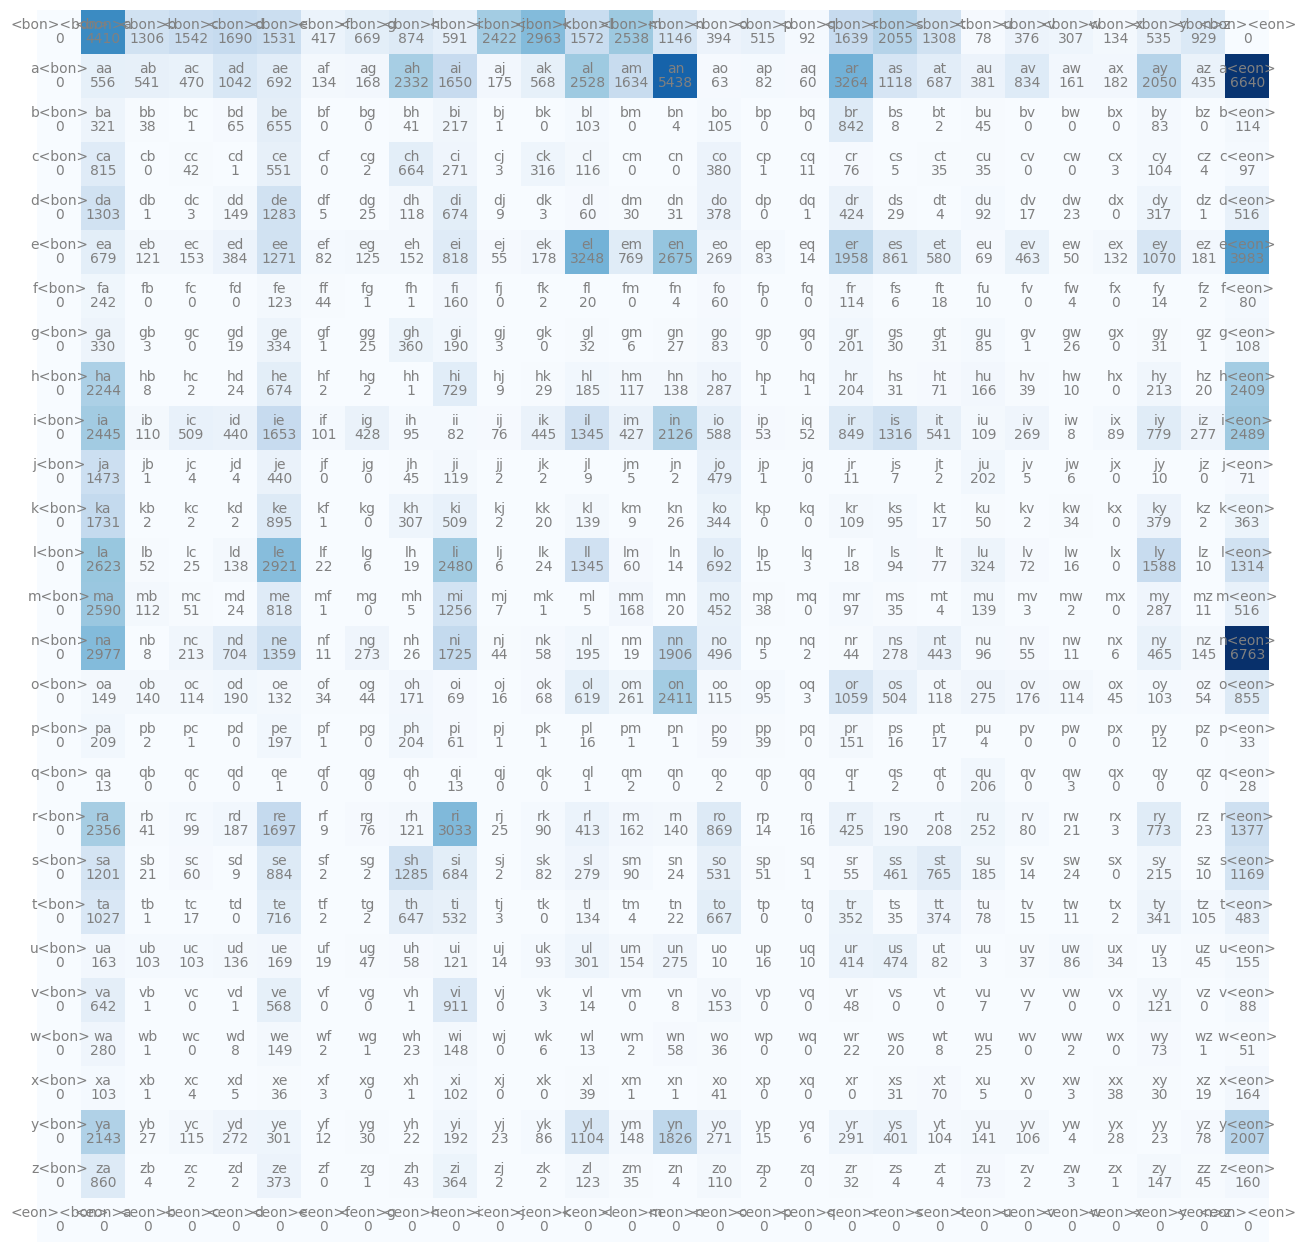

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [ ]:
p_0 = N[0].float()
p_0 /= p_0.sum()
p_0
c_0 = itos[torch.multinomial(p_0, num_samples=1, replacement=True).item()]
c_0

'd'

In [ ]:
# now the prefix is <bon>h
# now sample a character to follow h

p_1 = N[stoi[c_0]].float()
p_1 /= p_1.sum()
c_1 = itos[torch.multinomial(p_1, num_samples=1, replacement=True).item()]
c_1

'r'

In [ ]:
# now the prefix is <bon>an
# now sample a character to follow n

p_2 = N[stoi[c_1]].float()
p_2 /= p_2.sum()
c_2 = itos[torch.multinomial(p_2, num_samples=1, replacement=True).item()]
c_2

'l'

In [ ]:
# now the prefix is <bon>ana
# now sample a character to follow a

p_3 = N[stoi[c_2]].float()
p_3 /= p_3.sum()
c_3 = itos[torch.multinomial(p_3, num_samples=1, replacement=True).item()]
c_3

'i'

In [ ]:
c_list = []
ch = '<bon>'

while True:
    p = N[stoi[ch]].float()
    p /= p.sum()
    ch = itos[torch.multinomial(p, num_samples=1, replacement=True).item()]
    if ch == '<eon>':
        break
    c_list.append(ch)
print(''.join(c_list))

dan
